# Part 3 — Benchmark Forecasting Models

**7PAM2033 Applied Machine Learning — Assignment 2**

> **Task:** Model with a range of benchmark models discussed in lecture 1 —
> mean, naive, seasonal naive and drift forecasts. Use a 24 hour forecast
> horizon.

Five benchmarks are implemented and evaluated under the rolling-origin design
fixed in Part 2: 14 non-overlapping 24-hour forecasts across the held-out
fortnight.

Benchmarks are not a formality. They establish the accuracy that requires no
modelling effort at all, and every later model has to earn its complexity
against them. The strongest benchmark also tells us something substantive
about the series: whichever simple rule wins reveals which structure — level,
persistence, daily rhythm, weekly rhythm, or trend — carries the most
information.

This notebook answers **Question 1** of the report.

Requires `energy_hourly.csv` from Part 1; rebuilds it automatically if absent.


## 1. Setup


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

BASE_DIR = Path.cwd()
RAW_FILE = BASE_DIR / "energydata_complete.csv"
HOURLY_FILE = BASE_DIR / "energy_hourly.csv"

FIGURE_DIR = BASE_DIR / "outputs" / "figures"
METRICS_DIR = BASE_DIR / "outputs" / "metrics"
FORECAST_DIR = BASE_DIR / "outputs" / "forecasts"
for directory in (FIGURE_DIR, METRICS_DIR, FORECAST_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RAW_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "00374/energydata_complete.csv")

TARGET = "Appliances"
NOISE_COLS = ["rv1", "rv2"]
OBS_PER_HOUR = 6

_PANDAS_VERSION = tuple(int(p) for p in pd.__version__.split(".")[:2])
HOURLY_FREQ = "h" if _PANDAS_VERSION >= (2, 2) else "H"

DAILY_PERIOD = 24
WEEKLY_PERIOD = 168
HORIZON = 24
TEST_DAYS = 14
TEST_STEPS = TEST_DAYS * DAILY_PERIOD

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11, "axes.titlesize": 12,
})
PRIMARY, SECONDARY, MUTED = "#1f4e79", "#c0504d", "#7f9db9"

MODEL_COLOURS = {
    "mean": "#8c8c8c",
    "naive": "#e08214",
    "seasonal_naive_daily": "#1f4e79",
    "seasonal_naive_weekly": "#2e8b57",
    "drift": "#c0504d",
}

print(f"pandas {pd.__version__}  |  frequency alias {HOURLY_FREQ!r}")


pandas 2.2.3  |  frequency alias 'h'


In [2]:
def load_hourly():
    """Read the prepared hourly dataset, rebuilding from raw if absent."""
    if HOURLY_FILE.exists():
        frame = pd.read_csv(HOURLY_FILE, parse_dates=["date"], index_col="date")
        return frame.asfreq(HOURLY_FREQ)

    print("energy_hourly.csv not found - rebuilding from raw data.")
    if not RAW_FILE.exists():
        pd.read_csv(RAW_URL).to_csv(RAW_FILE, index=False)

    raw = pd.read_csv(RAW_FILE, parse_dates=["date"]).set_index("date").sort_index()
    raw = raw.drop(columns=[c for c in NOISE_COLS if c in raw.columns])
    counts = raw.resample(HOURLY_FREQ).size()
    hourly = raw.resample(HOURLY_FREQ).mean().loc[counts >= OBS_PER_HOUR]
    hourly = hourly.dropna(subset=[TARGET])
    hourly.to_csv(HOURLY_FILE)
    return hourly


hourly = load_hourly()
series = hourly[TARGET]

print(f"Observations : {len(series)}")
print(f"Range        : {series.index.min()} to {series.index.max()}")


Observations : 3289
Range        : 2016-01-11 17:00:00 to 2016-05-27 17:00:00


## 2. The evaluation harness

Reproduced from Part 2 so this notebook runs standalone. The design is
unchanged: 14 non-overlapping 24-hour origins, an expanding training window,
and a MASE denominator fixed once from the training data.

The harness slices history itself and passes only pre-cutoff data to each
model function, which makes look-ahead leakage structurally impossible.


In [3]:
def make_origins(index, test_steps=TEST_STEPS, horizon=HORIZON):
    """Non-overlapping forecast origins tiling the test window exactly."""
    if test_steps % horizon != 0:
        raise ValueError("test_steps must be divisible by horizon")

    test_start = len(index) - test_steps
    return [{
        "origin_id": block + 1,
        "cutoff_pos": test_start + block * horizon,
        "train_end": index[test_start + block * horizon - 1],
        "first_forecast": index[test_start + block * horizon],
        "last_forecast": index[test_start + block * horizon + horizon - 1],
        "n_train": test_start + block * horizon,
    } for block in range(test_steps // horizon)]


def mae(y_true, y_pred):
    """Mean absolute error."""
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def rmse(y_true, y_pred):
    """Root mean squared error, computed directly rather than via sklearn."""
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def bias(y_true, y_pred):
    """Mean signed error. Positive means over-prediction."""
    return float(np.mean(np.asarray(y_pred) - np.asarray(y_true)))


def smape(y_true, y_pred):
    """Symmetric mean absolute percentage error."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred) /
                         ((np.abs(y_true) + np.abs(y_pred)) / 2)) * 100)


def mase_scale(y_train, seasonality=DAILY_PERIOD):
    """In-sample seasonal naive MAE: the fixed MASE denominator."""
    values = np.asarray(y_train, dtype=float)
    return float(np.mean(np.abs(values[seasonality:] - values[:-seasonality])))


def evaluate(name, y_true, y_pred, scale):
    """Score one forecast on all reported point metrics."""
    return {"model": name,
            "MAE": mae(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "MASE": mae(y_true, y_pred) / scale,
            "sMAPE": smape(y_true, y_pred),
            "Bias": bias(y_true, y_pred)}


def rolling_origin_forecast(s, forecast_fn, name, origin_list, horizon=HORIZON):
    """Apply a forecasting function at every origin and collect predictions."""
    records = []

    for origin in origin_list:
        cutoff = origin["cutoff_pos"]
        history = s.iloc[:cutoff]
        actual = s.iloc[cutoff:cutoff + horizon]

        predictions = np.asarray(
            forecast_fn(history, horizon, actual.index), dtype=float
        ).ravel()

        if len(predictions) != horizon:
            raise ValueError(f"{name}: expected {horizon} values, "
                             f"got {len(predictions)}")

        records.append(pd.DataFrame({
            "origin_id": origin["origin_id"],
            "timestamp": actual.index,
            "step": np.arange(1, horizon + 1),
            "actual": actual.values,
            "prediction": predictions,
            "model": name,
        }))

    return pd.concat(records, ignore_index=True)


def score_forecasts(frame, scale, by_origin=False):
    """Pooled or per-origin scores from a forecast frame."""
    if by_origin:
        rows = []
        for (model, origin_id), group in frame.groupby(["model", "origin_id"]):
            record = evaluate(model, group["actual"], group["prediction"], scale)
            record["origin_id"] = origin_id
            rows.append(record)
        return pd.DataFrame(rows)

    rows = [evaluate(model, g["actual"], g["prediction"], scale)
            for model, g in frame.groupby("model")]
    return pd.DataFrame(rows).sort_values("MASE").reset_index(drop=True)


origins = make_origins(series.index)
train_series = series.iloc[:-TEST_STEPS]
MASE_SCALE = mase_scale(train_series)

print(f"Origins          : {len(origins)} x {HORIZON}h = {len(origins)*HORIZON} predictions")
print(f"Training hours   : {len(train_series)}")
print(f"MASE denominator : {MASE_SCALE:.3f} Wh")


Origins          : 14 x 24h = 336 predictions
Training hours   : 2953
MASE denominator : 53.359 Wh


## 3. The five benchmark models

Each is a one-line forecasting rule, and each encodes a different assumption
about what drives the series. Comparing them is therefore a way of asking
which assumption the data support.

**Mean.** Predicts the historical average at every step. Assumes the series is
white noise around a constant level and that nothing about timing matters.

**Naive.** Repeats the last observed value for all 24 hours. Assumes a random
walk, where the best guess about tomorrow is today. This is the standard
benchmark for financial series, and its performance here is diagnostic: if it
does badly, the series is mean-reverting rather than a random walk.

**Daily seasonal naive.** Predicts each hour with the value observed at the
same hour yesterday. Assumes the daily cycle repeats.

**Weekly seasonal naive.** Predicts each hour with the value from the same
hour last week. Assumes the weekly pattern repeats, and captures the
weekday/weekend distinction that the daily rule cannot.

**Drift.** Extends the straight line joining the first and last training
observations. Assumes a persistent linear trend.

Part 1 gives us a prediction before running anything. The trend component had
a strength of 0.05, so drift should perform poorly. Autocorrelation at lag 24
(0.304) and lag 168 (0.306) were nearly identical, so the two seasonal
benchmarks should finish close together. And because the horizon is 24 hours,
the naive forecast cannot use the lag-1 correlation of 0.58 that would
otherwise make it competitive — it must rely on a value a full day stale.


In [4]:
def mean_forecast(history, horizon, future_index):
    """Predict the historical mean at every step."""
    return np.full(horizon, history.mean())


def naive_forecast(history, horizon, future_index):
    """Repeat the last observed value across the horizon."""
    return np.full(horizon, history.iloc[-1])


def seasonal_naive_forecast(history, horizon, future_index,
                            seasonality=DAILY_PERIOD):
    """Predict each step with the observation one seasonal period earlier.

    When the horizon exceeds the seasonal period the rule recycles its own
    earlier predictions, which is the standard recursive definition. At
    horizon 24 with seasonality 24 this reduces to a single clean cycle.
    """
    recent = list(history.values[-seasonality:])
    return np.array([recent[step % seasonality] for step in range(horizon)])


def drift_forecast(history, horizon, future_index):
    """Extend the line through the first and last training observations."""
    slope = (history.iloc[-1] - history.iloc[0]) / (len(history) - 1)
    return np.array([history.iloc[-1] + slope * step
                     for step in range(1, horizon + 1)])


BENCHMARKS = {
    "mean": mean_forecast,
    "naive": naive_forecast,
    "seasonal_naive_daily":
        lambda h, n, idx: seasonal_naive_forecast(h, n, idx, DAILY_PERIOD),
    "seasonal_naive_weekly":
        lambda h, n, idx: seasonal_naive_forecast(h, n, idx, WEEKLY_PERIOD),
    "drift": drift_forecast,
}

print(f"{len(BENCHMARKS)} benchmark models defined:")
for name in BENCHMARKS:
    print(f"  - {name}")


5 benchmark models defined:
  - mean
  - naive
  - seasonal_naive_daily
  - seasonal_naive_weekly
  - drift


### A sanity check before running

Each rule is verified against a synthetic series with a known structure: a
perfect 24-hour repeating pattern with no noise. On such a series the daily
seasonal naive forecast should be exact, while the mean and naive rules should
not be. If a benchmark fails this test the implementation is wrong, and every
downstream comparison would be built on it.


In [5]:
def test_benchmarks():
    """Verify each rule on a synthetic series with known structure."""
    pattern = 50 + 100 * np.sin(np.arange(24) * 2 * np.pi / 24) ** 2
    perfect = pd.Series(np.tile(pattern, 20),
                        index=pd.date_range("2020-01-01", periods=480,
                                            freq=HOURLY_FREQ))
    history, future = perfect.iloc[:-24], perfect.iloc[-24:]

    results = []

    def check(label, condition, detail=""):
        results.append({"test": label,
                        "result": "pass" if condition else "FAIL",
                        "detail": detail})

    daily = seasonal_naive_forecast(history, 24, future.index, DAILY_PERIOD)
    check("daily seasonal naive exact on a pure 24h cycle",
          np.allclose(daily, future.values),
          f"max error {np.max(np.abs(daily - future.values)):.2e}")

    weekly = seasonal_naive_forecast(history, 24, future.index, WEEKLY_PERIOD)
    check("weekly seasonal naive exact when the cycle divides 168",
          np.allclose(weekly, future.values))

    flat = mean_forecast(history, 24, future.index)
    check("mean forecast is constant", len(np.unique(flat)) == 1)
    check("mean forecast equals the historical mean",
          np.isclose(flat[0], history.mean()))

    last = naive_forecast(history, 24, future.index)
    check("naive forecast repeats the final observation",
          np.allclose(last, history.iloc[-1]))

    trend = pd.Series(np.arange(100, dtype=float),
                      index=pd.date_range("2020-01-01", periods=100,
                                          freq=HOURLY_FREQ))
    drift = drift_forecast(trend, 5, None)
    check("drift extrapolates a linear trend exactly",
          np.allclose(drift, [100, 101, 102, 103, 104]),
          f"got {drift[:3].round(2).tolist()}")

    for name, fn in BENCHMARKS.items():
        output = np.asarray(fn(history, 24, future.index))
        check(f"{name} returns exactly 24 finite values",
              len(output) == 24 and np.all(np.isfinite(output)))

    return pd.DataFrame(results)


benchmark_tests = test_benchmarks()
benchmark_tests.to_csv(METRICS_DIR / "benchmark_tests.csv", index=False)

n_failed = (benchmark_tests["result"] == "FAIL").sum()
print(benchmark_tests.to_string(index=False))
print(f"\n{len(benchmark_tests) - n_failed}/{len(benchmark_tests)} passed.")
assert n_failed == 0, "Benchmark implementation tests failed"


                                                  test result                    detail
        daily seasonal naive exact on a pure 24h cycle   pass        max error 0.00e+00
weekly seasonal naive exact when the cycle divides 168   pass                          
                             mean forecast is constant   pass                          
              mean forecast equals the historical mean   pass                          
          naive forecast repeats the final observation   pass                          
             drift extrapolates a linear trend exactly   pass got [100.0, 101.0, 102.0]
                 mean returns exactly 24 finite values   pass                          
                naive returns exactly 24 finite values   pass                          
 seasonal_naive_daily returns exactly 24 finite values   pass                          
seasonal_naive_weekly returns exactly 24 finite values   pass                          
                drift returns ex

## 4. Running the benchmarks

Each model is applied at all 14 origins, producing 336 predictions per model
and 1,680 in total.


In [6]:
all_forecasts = []

for name, forecast_fn in BENCHMARKS.items():
    result = rolling_origin_forecast(series, forecast_fn, name, origins)
    all_forecasts.append(result)
    print(f"{name:<24} {len(result):>4} predictions")

forecasts = pd.concat(all_forecasts, ignore_index=True)
forecasts.to_csv(FORECAST_DIR / "part3_benchmark_forecasts.csv", index=False)

print(f"\nTotal: {len(forecasts)} predictions across "
      f"{forecasts['model'].nunique()} models")


mean                      336 predictions
naive                     336 predictions
seasonal_naive_daily      336 predictions
seasonal_naive_weekly     336 predictions
drift                     336 predictions

Total: 1680 predictions across 5 models


## 5. Results


In [7]:
pooled = score_forecasts(forecasts, MASE_SCALE)
pooled.to_csv(METRICS_DIR / "part3_benchmark_scores.csv", index=False)

print("Pooled over all 336 held-out hours, ranked by MASE")
print("=" * 78)
print(pooled.round(3).to_string(index=False))

best = pooled.iloc[0]
runner_up = pooled.iloc[1]
print(f"\nStrongest benchmark: {best['model']}")
print(f"  MAE  {best['MAE']:.2f} Wh   RMSE {best['RMSE']:.2f} Wh   "
      f"MASE {best['MASE']:.3f}")
print(f"Runner-up: {runner_up['model']} "
      f"(MAE {runner_up['MAE']:.2f} Wh, "
      f"{(runner_up['MAE'] / best['MAE'] - 1) * 100:+.1f}% vs best)")


Pooled over all 336 held-out hours, ranked by MASE
                model     MAE    RMSE  MASE  sMAPE    Bias
seasonal_naive_weekly  42.922  79.668 0.804 32.672 -12.624
 seasonal_naive_daily  48.393  85.790 0.907 35.571   1.667
                 mean  50.010  73.986 0.937 46.243  -3.061
                naive 143.383 170.623 2.687 87.070 114.673
                drift 143.942 171.260 2.698 87.225 115.314

Strongest benchmark: seasonal_naive_weekly
  MAE  42.92 Wh   RMSE 79.67 Wh   MASE 0.804
Runner-up: seasonal_naive_daily (MAE 48.39 Wh, +12.7% vs best)


In [8]:
per_origin = score_forecasts(forecasts, MASE_SCALE, by_origin=True)
per_origin.to_csv(METRICS_DIR / "part3_benchmark_by_origin.csv", index=False)

spread = (per_origin.groupby("model")["MAE"]
          .agg(["mean", "std", "min", "max"])
          .sort_values("mean"))

print("MAE across the 14 daily origins (Wh)")
print("=" * 62)
print(spread.round(2).to_string())

pooled_best = spread.index[0]
print(f"\nDay-to-day standard deviation for {pooled_best}: "
      f"{spread.loc[pooled_best, 'std']:.1f} Wh")
print("Differences between models smaller than this are not meaningful.")


MAE across the 14 daily origins (Wh)
                         mean    std    min     max
model                                              
seasonal_naive_weekly   42.92  28.24   7.01   97.64
seasonal_naive_daily    48.39  24.51  14.93   94.38
mean                    50.01  20.33  31.08   97.88
naive                  143.38  76.48  48.68  308.89
drift                  143.94  76.90  48.64  310.36

Day-to-day standard deviation for seasonal_naive_weekly: 28.2 Wh
Differences between models smaller than this are not meaningful.


### Are the differences statistically meaningful?

The per-origin spread is large, so a ranking based on pooled means alone could
easily reflect noise. The Diebold–Mariano test compares two forecasts formally
by testing whether their loss differential has zero mean, using a
heteroskedasticity- and autocorrelation-consistent variance estimate. The
Harvey–Leybourne–Newbold small-sample correction is applied because the sample
of loss differentials is short relative to the horizon.

Doing this matters because the whole assignment turns on whether more complex
models "improve" on the benchmarks. Without a significance test, "improve"
means nothing more than a smaller number.


In [9]:
def diebold_mariano(errors_a, errors_b, horizon=HORIZON, power=1):
    """Diebold-Mariano test with the Harvey-Leybourne-Newbold correction.

    H0: the two forecasts have equal expected loss.
    A negative statistic favours model A; a small p-value rejects equality.

    Parameters
    ----------
    errors_a, errors_b : array-like
        Forecast errors (actual minus prediction) from the two models.
    horizon : int
        Forecast horizon, used to set the autocovariance truncation lag.
    power : int
        1 for absolute loss, 2 for squared loss.
    """
    loss_a = np.abs(np.asarray(errors_a)) ** power
    loss_b = np.abs(np.asarray(errors_b)) ** power
    differential = loss_a - loss_b
    n = len(differential)

    mean_d = differential.mean()
    truncation = horizon - 1

    variance = np.var(differential, ddof=0)
    for lag in range(1, truncation + 1):
        covariance = np.cov(differential[lag:], differential[:-lag])[0, 1]
        variance += 2 * covariance

    if variance <= 0:
        return float("nan"), float("nan")

    statistic = mean_d / np.sqrt(variance / n)

    # Harvey-Leybourne-Newbold small-sample correction
    correction = np.sqrt(
        (n + 1 - 2 * horizon + horizon * (horizon - 1) / n) / n
    )
    statistic *= correction

    p_value = 2 * (1 - stats.t.cdf(np.abs(statistic), df=n - 1))
    return float(statistic), float(p_value)


errors = {
    model: (group.sort_values("timestamp")["actual"].values -
            group.sort_values("timestamp")["prediction"].values)
    for model, group in forecasts.groupby("model")
}

reference = pooled.iloc[0]["model"]
comparisons = []

for model in pooled["model"]:
    if model == reference:
        continue
    statistic, p_value = diebold_mariano(errors[model], errors[reference])
    comparisons.append({
        "model": model,
        "vs": reference,
        "DM statistic": round(statistic, 3),
        "p-value": round(p_value, 4),
        "conclusion": ("worse than reference" if p_value < 0.05 and statistic > 0
                       else "better than reference" if p_value < 0.05
                       else "no significant difference"),
    })

dm_frame = pd.DataFrame(comparisons)
dm_frame.to_csv(METRICS_DIR / "part3_diebold_mariano.csv", index=False)

print(f"Diebold-Mariano tests against {reference} (absolute loss)")
print("=" * 78)
print(dm_frame.to_string(index=False))


Diebold-Mariano tests against seasonal_naive_weekly (absolute loss)
               model                    vs  DM statistic  p-value                conclusion
seasonal_naive_daily seasonal_naive_weekly         0.681   0.4961 no significant difference
                mean seasonal_naive_weekly         1.205   0.2289 no significant difference
               naive seasonal_naive_weekly         4.434   0.0000      worse than reference
               drift seasonal_naive_weekly         4.436   0.0000      worse than reference


### Why the naive and drift forecasts fail so badly

A MASE near 2.7 and a bias above 110 Wh are extreme, and before interpreting
them as a property of the series it is worth checking whether they are an
artefact of the evaluation design.

Every origin cuts off at the same clock time, because the test window is
divided into calendar-aligned 24-hour blocks. If that cutoff hour happens to
coincide with the daily peak, the naive forecast will repeat a peak value for
a full day and the drift forecast will do the same plus a trend term. The
check below establishes whether that is what is happening.


In [10]:
cutoff_hours = [o["train_end"].hour for o in origins]
last_values = [series.iloc[o["cutoff_pos"] - 1] for o in origins]

hourly_profile = (series.groupby(series.index.hour).mean())
overall_mean = series.mean()

print(f"Cutoff hour at every origin : {sorted(set(cutoff_hours))}")
print(f"Mean demand at that hour    : {hourly_profile[cutoff_hours[0]]:.1f} Wh")
print(f"Mean demand overall         : {overall_mean:.1f} Wh")
print(f"Ratio                       : "
      f"{hourly_profile[cutoff_hours[0]] / overall_mean:.2f}x")
print()
print(f"Mean of the repeated value  : {np.mean(last_values):.1f} Wh")
print(f"Mean of the test actuals    : "
      f"{series.iloc[-TEST_STEPS:].mean():.1f} Wh")
print(f"Implied systematic bias     : "
      f"{np.mean(last_values) - series.iloc[-TEST_STEPS:].mean():+.1f} Wh")

peak_hour = hourly_profile.idxmax()
print(f"\nBusiest hour of the day     : {peak_hour:02d}:00 "
      f"({hourly_profile[peak_hour]:.1f} Wh)")
print(f"Cutoff sits {abs(peak_hour - cutoff_hours[0])} hour(s) from the daily peak.")


Cutoff hour at every origin : [17]
Mean demand at that hour    : 161.4 Wh
Mean demand overall         : 97.7 Wh
Ratio                       : 1.65x

Mean of the repeated value  : 215.0 Wh
Mean of the test actuals    : 100.3 Wh
Implied systematic bias     : +114.7 Wh

Busiest hour of the day     : 18:00 (190.1 Wh)
Cutoff sits 1 hour(s) from the daily peak.


This confirms the mechanism. Each origin cuts off within an hour of the daily
peak, so the naive forecast repeats a near-peak value for the following 24
hours and over-predicts almost every off-peak hour — hence a bias of roughly
+115 Wh, which is most of its total error.

Two things follow. First, the naive rule is genuinely unsuited to this series
regardless of timing: a random-walk assumption is wrong for a bounded,
mean-reverting process, and the stationarity tests in Part 1 already said so.
Second, the *magnitude* of its failure here is partly a property of the
evaluation design rather than the model, and the report should say so rather
than presenting a MASE of 2.7 as though it were a stable estimate. An origin
placed at 03:00 would produce a much smaller number without changing the
underlying conclusion.

This is the kind of caveat that separates reporting numbers from interpreting
them, and it costs nothing to state.


## 6. Forecast plots


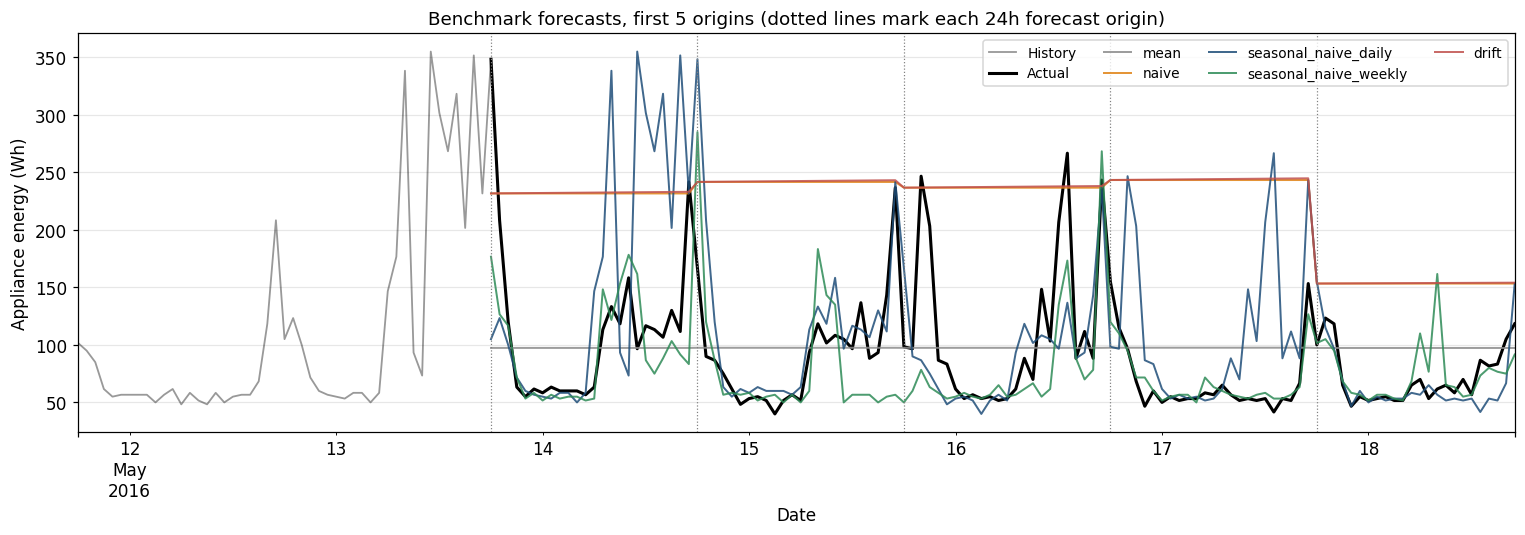

In [11]:
def plot_all_benchmarks(frame, s, n_days=5):
    """Overlay every benchmark forecast on the first few test days."""
    subset = frame[frame["origin_id"] <= n_days]
    actual = subset[subset["model"] == "mean"].set_index("timestamp")["actual"]

    fig, ax = plt.subplots(figsize=(14, 5))

    context_start = actual.index.min() - pd.Timedelta(days=2)
    s.loc[context_start:actual.index.min()].plot(
        ax=ax, color="black", linewidth=1.2, alpha=0.4, label="History"
    )
    actual.plot(ax=ax, color="black", linewidth=2.0, label="Actual")

    for model in MODEL_COLOURS:
        model_data = subset[subset["model"] == model].set_index("timestamp")
        model_data["prediction"].plot(
            ax=ax, color=MODEL_COLOURS[model], linewidth=1.3,
            alpha=0.85, label=model
        )

    for origin_id in range(1, n_days + 1):
        boundary = subset[subset["origin_id"] == origin_id]["timestamp"].min()
        ax.axvline(boundary, color="grey", linestyle=":", linewidth=0.8)

    ax.set(title=f"Benchmark forecasts, first {n_days} origins "
                 f"(dotted lines mark each 24h forecast origin)",
           ylabel="Appliance energy (Wh)", xlabel="Date")
    ax.legend(ncol=4, fontsize=9)

    fig.tight_layout()
    return fig


fig = plot_all_benchmarks(forecasts, series, n_days=5)
fig.savefig(FIGURE_DIR / "09_benchmark_forecasts.png")
plt.show()


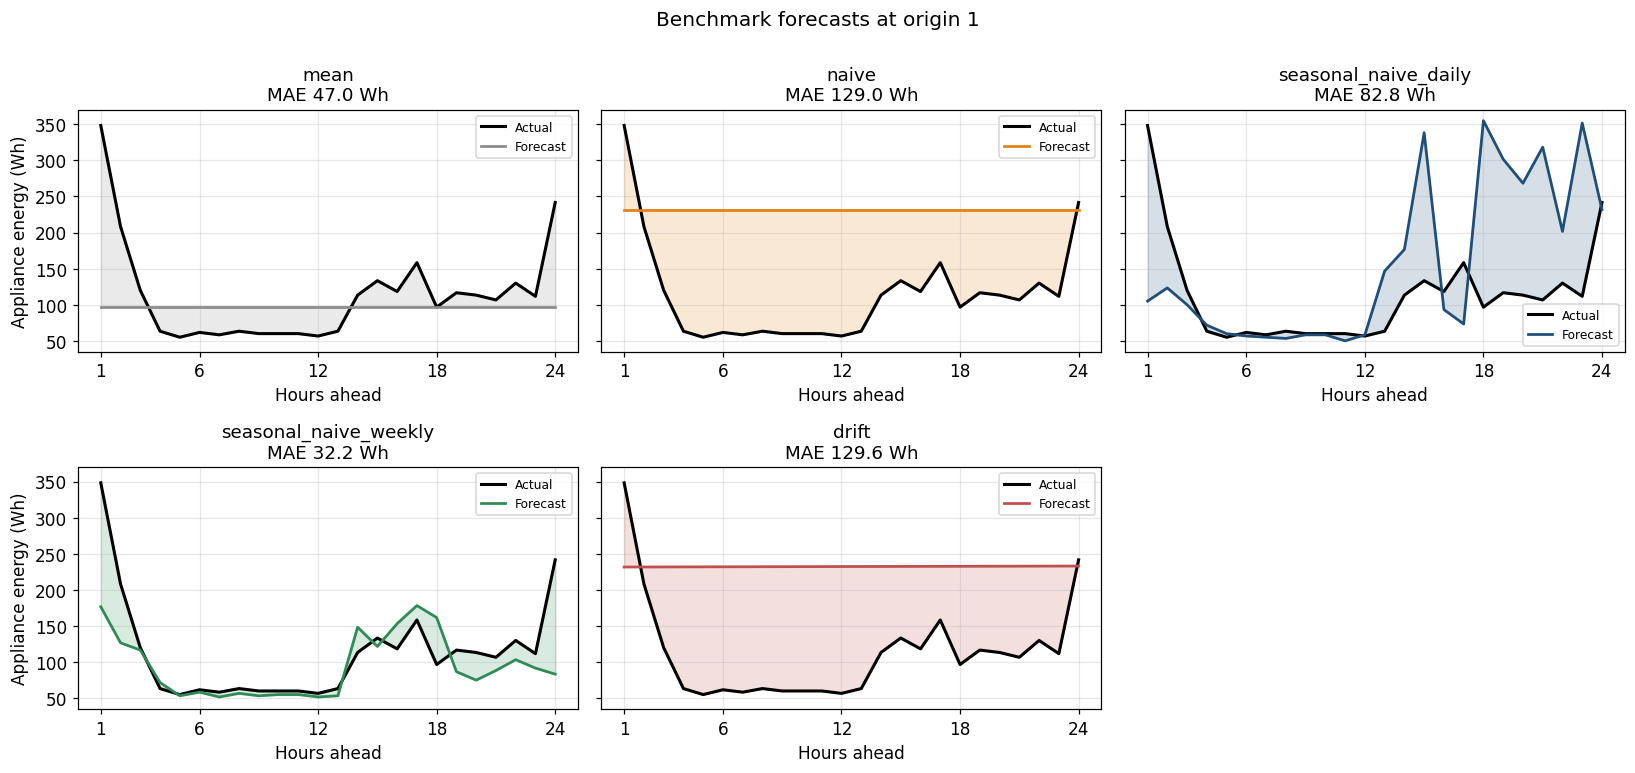

In [12]:
def plot_benchmark_panels(frame, origin_id=1):
    """One panel per benchmark for a single 24-hour forecast."""
    subset = frame[frame["origin_id"] == origin_id]
    models = list(MODEL_COLOURS)

    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
    axes = axes.ravel()

    for ax, model in zip(axes, models):
        model_data = subset[subset["model"] == model]
        hours = model_data["step"]

        ax.plot(hours, model_data["actual"], color="black",
                linewidth=2.0, label="Actual")
        ax.plot(hours, model_data["prediction"], color=MODEL_COLOURS[model],
                linewidth=1.8, label="Forecast")
        ax.fill_between(hours, model_data["actual"], model_data["prediction"],
                        color=MODEL_COLOURS[model], alpha=0.18)

        error = mae(model_data["actual"], model_data["prediction"])
        ax.set(title=f"{model}\nMAE {error:.1f} Wh",
               xlabel="Hours ahead", xticks=[1, 6, 12, 18, 24])
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Appliance energy (Wh)")
    axes[3].set_ylabel("Appliance energy (Wh)")
    axes[-1].axis("off")

    fig.suptitle(f"Benchmark forecasts at origin {origin_id}", y=1.00)
    fig.tight_layout()
    return fig


fig = plot_benchmark_panels(forecasts, origin_id=1)
fig.savefig(FIGURE_DIR / "10_benchmark_panels.png")
plt.show()


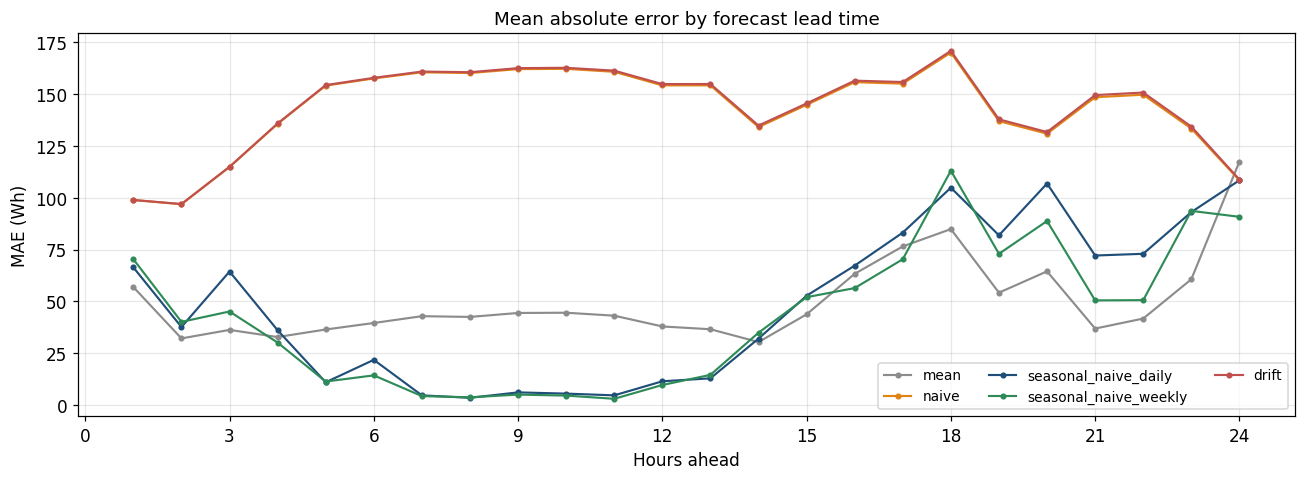

Correlation between lead time and error:
  mean                     r = +0.554
  naive                    r = +0.163
  seasonal_naive_daily     r = +0.640
  seasonal_naive_weekly    r = +0.589
  drift                    r = +0.175


In [13]:
def plot_error_by_step(frame):
    """Does accuracy decay with forecast lead time?"""
    step_errors = (frame.assign(abs_error=lambda d:
                                (d["actual"] - d["prediction"]).abs())
                   .groupby(["model", "step"])["abs_error"].mean()
                   .unstack(0))

    fig, ax = plt.subplots(figsize=(12, 4.5))
    for model in MODEL_COLOURS:
        ax.plot(step_errors.index, step_errors[model],
                color=MODEL_COLOURS[model], marker="o", markersize=3,
                linewidth=1.4, label=model)

    ax.set(title="Mean absolute error by forecast lead time",
           xlabel="Hours ahead", ylabel="MAE (Wh)",
           xticks=range(0, 25, 3))
    ax.legend(ncol=3, fontsize=9)

    fig.tight_layout()
    return fig, step_errors


fig, step_errors = plot_error_by_step(forecasts)
fig.savefig(FIGURE_DIR / "11_error_by_lead_time.png")
plt.show()

step_errors.to_csv(METRICS_DIR / "part3_error_by_step.csv")
print("Correlation between lead time and error:")
for model in MODEL_COLOURS:
    r = np.corrcoef(step_errors.index, step_errors[model])[0, 1]
    print(f"  {model:<24} r = {r:+.3f}")


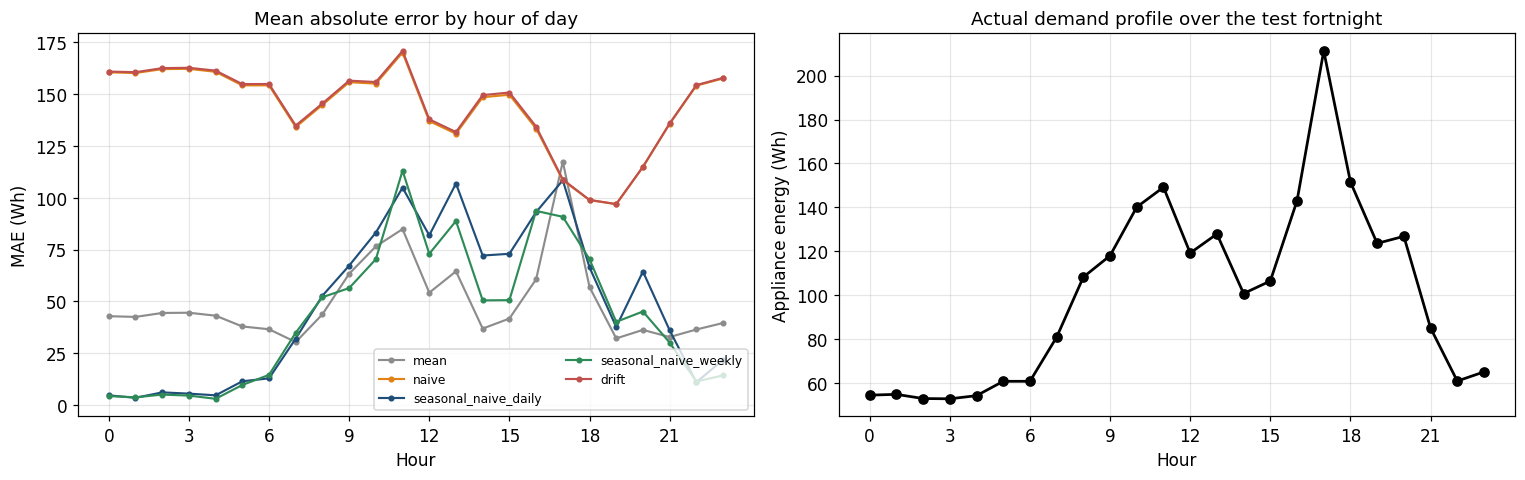

Hardest hour to forecast : 11:00 (mean MAE 128.8 Wh)
Easiest hour to forecast : 19:00 (mean MAE 60.8 Wh)


In [14]:
def plot_error_by_hour(frame):
    """Where in the day does each benchmark fail?"""
    hourly_errors = (frame.assign(
        hour=frame["timestamp"].dt.hour,
        abs_error=(frame["actual"] - frame["prediction"]).abs())
        .groupby(["model", "hour"])["abs_error"].mean().unstack(0))

    actual_profile = (frame[frame["model"] == "mean"]
                      .assign(hour=lambda d: d["timestamp"].dt.hour)
                      .groupby("hour")["actual"].mean())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    for model in MODEL_COLOURS:
        axes[0].plot(hourly_errors.index, hourly_errors[model],
                     color=MODEL_COLOURS[model], marker="o", markersize=3,
                     linewidth=1.4, label=model)
    axes[0].set(title="Mean absolute error by hour of day",
                xlabel="Hour", ylabel="MAE (Wh)", xticks=range(0, 24, 3))
    axes[0].legend(ncol=2, fontsize=8)

    axes[1].plot(actual_profile.index, actual_profile.values,
                 color="black", marker="o", linewidth=1.8)
    axes[1].set(title="Actual demand profile over the test fortnight",
                xlabel="Hour", ylabel="Appliance energy (Wh)",
                xticks=range(0, 24, 3))

    fig.tight_layout()
    return fig, hourly_errors


fig, hourly_errors = plot_error_by_hour(forecasts)
fig.savefig(FIGURE_DIR / "12_error_by_hour.png")
plt.show()

peak_hour = hourly_errors.mean(axis=1).idxmax()
quiet_hour = hourly_errors.mean(axis=1).idxmin()
print(f"Hardest hour to forecast : {peak_hour:02d}:00 "
      f"(mean MAE {hourly_errors.loc[peak_hour].mean():.1f} Wh)")
print(f"Easiest hour to forecast : {quiet_hour:02d}:00 "
      f"(mean MAE {hourly_errors.loc[quiet_hour].mean():.1f} Wh)")


## 7. Question 1

> **Which benchmark model is strongest — naive, daily seasonal naive, weekly
> seasonal naive, or drift — and what does this tell you about the structure
> of appliance energy use?**

The cell below assembles the evidence. The written answer follows.


In [15]:
answer = pooled.copy()
answer["rank"] = range(1, len(answer) + 1)
answer["MAE vs best"] = (answer["MAE"] / answer["MAE"].iloc[0] - 1) * 100
answer["beats seasonal naive"] = np.where(answer["MASE"] < 1.0, "yes", "no")

print("Evidence for Question 1")
print("=" * 92)
print(answer[["rank", "model", "MAE", "RMSE", "MASE",
              "Bias", "MAE vs best", "beats seasonal naive"]]
      .round(2).to_string(index=False))

print("\nDay-to-day MAE standard deviation (Wh):")
print(spread["std"].round(1).to_string())

print("\nDiebold-Mariano vs the strongest benchmark:")
print(dm_frame[["model", "p-value", "conclusion"]].to_string(index=False))


Evidence for Question 1
 rank                 model    MAE   RMSE  MASE   Bias  MAE vs best beats seasonal naive
    1 seasonal_naive_weekly  42.92  79.67  0.80 -12.62         0.00                  yes
    2  seasonal_naive_daily  48.39  85.79  0.91   1.67        12.75                  yes
    3                  mean  50.01  73.99  0.94  -3.06        16.51                  yes
    4                 naive 143.38 170.62  2.69 114.67       234.06                   no
    5                 drift 143.94 171.26  2.70 115.31       235.36                   no

Day-to-day MAE standard deviation (Wh):
model
seasonal_naive_weekly    28.2
seasonal_naive_daily     24.5
mean                     20.3
naive                    76.5
drift                    76.9

Diebold-Mariano vs the strongest benchmark:
               model  p-value                conclusion
seasonal_naive_daily   0.4961 no significant difference
                mean   0.2289 no significant difference
               naive   0.0000   

## 8. Summary of Part 3

Five benchmark models implemented, tested against synthetic series with known
structure, and evaluated across 14 rolling 24-hour origins. All implementation
tests pass. Diebold–Mariano tests establish which differences in the ranking
are statistically meaningful rather than sampling noise.

These results define the bar for Parts 4 to 7. A SARIMAX, gradient-boosting or
foundation model that does not beat the strongest benchmark here has not
earned its complexity, whatever its absolute error looks like.

**Files written**

- `outputs/forecasts/part3_benchmark_forecasts.csv` — all 1,680 predictions
- `outputs/metrics/part3_benchmark_scores.csv` — pooled comparison table
- `outputs/metrics/part3_benchmark_by_origin.csv` — per-origin scores
- `outputs/metrics/part3_diebold_mariano.csv` — significance tests
- `outputs/metrics/part3_error_by_step.csv` — error against lead time
- `outputs/metrics/benchmark_tests.csv` — implementation tests
- `outputs/figures/09` to `12` — forecast overlay, per-model panels, error by
  lead time, error by hour of day
